# BÀI 4: GOM CỤM DỮ LIỆU (CLUSTERING)

**Mục tiêu:** Áp dụng thuật toán học không giám sát K-Means để phân nhóm dữ liệu tự động dựa trên độ tương đồng:
1. **D2 (Hotel Bookings):** Phân khúc khách hàng dựa trên thói quen đặt phòng (`lead_time` và `adr`).
2. **D3 (NSL-KDD):** Phân nhóm hành vi lưu lượng mạng (`src_bytes` và `dst_bytes`) để rà soát bất thường.

---
## 4.1. Triển khai K-Means phân khúc khách hàng trên D2 (Hotel Bookings)

### 🏨 PHÂN CỤM KHÁCH HÀNG (D2)

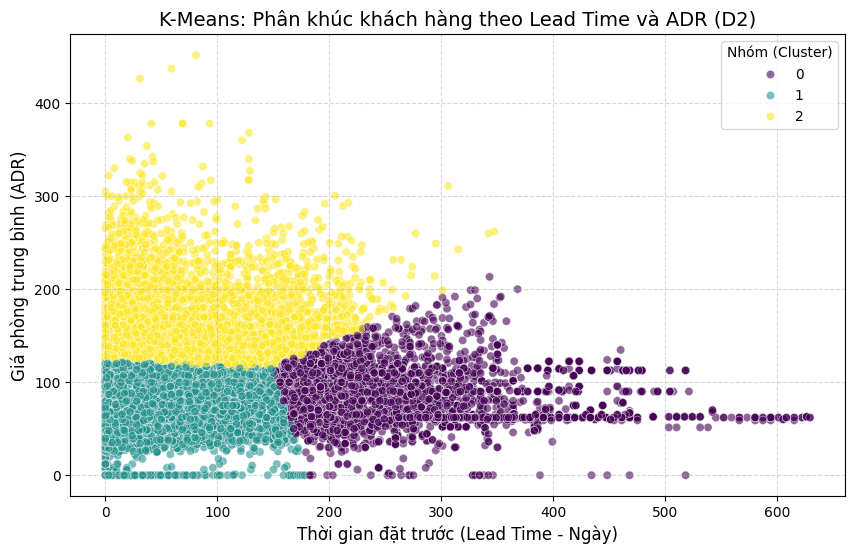

In [19]:
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# BÀI 4.1: GOM CỤM K-MEANS TRÊN D2 (HOTEL BOOKINGS)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Markdown

display(Markdown("### 🏨 PHÂN CỤM KHÁCH HÀNG (D2)"))

try:
    # 1. Đọc dữ liệu
    df2 = pd.read_csv('D2_Cleaned_HotelBookings.csv')

    # 2. Chọn đặc trưng: Thời gian đặt trước (lead_time) và Giá phòng (adr)
    X_cluster_d2 = df2[['lead_time', 'adr']].dropna()

    # Lọc bỏ nhiễu (outliers) giá phòng > 1000 để biểu đồ không bị méo
    X_cluster_d2 = X_cluster_d2[X_cluster_d2['adr'] < 1000]

    # 3. Chuẩn hóa dữ liệu (Đưa về cùng thang đo)
    scaler2 = StandardScaler()
    X_scaled_d2 = scaler2.fit_transform(X_cluster_d2)

    # 4. Huấn luyện K-Means với 3 cụm (k=3)
    kmeans_d2 = KMeans(n_clusters=3, random_state=42, n_init=10)
    X_cluster_d2['Cluster'] = kmeans_d2.fit_predict(X_scaled_d2)

    # 5. Trực quan hóa kết quả
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=X_cluster_d2, x='lead_time', y='adr', hue='Cluster', palette='viridis', alpha=0.6)
    plt.title('K-Means: Phân khúc khách hàng theo Lead Time và ADR (D2)', fontsize=14)
    plt.xlabel('Thời gian đặt trước (Lead Time - Ngày)', fontsize=12)
    plt.ylabel('Giá phòng trung bình (ADR)', fontsize=12)
    plt.legend(title='Nhóm (Cluster)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

except Exception as e:
    print(f"LỖI: {e}")

---
## 4.2. Triển khai K-Means nhận diện hành vi mạng trên D3 (NSL-KDD)

### 🛡️ PHÂN CỤM LƯU LƯỢNG MẠNG (D3)

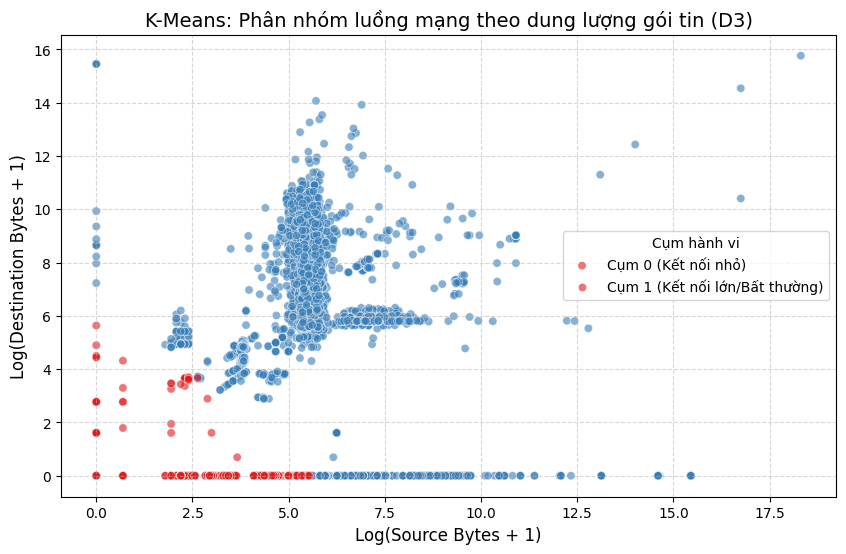

In [20]:
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# BÀI 4.2: GOM CỤM K-MEANS TRÊN D3 (NSL-KDD)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Markdown

display(Markdown("### 🛡️ PHÂN CỤM LƯU LƯỢNG MẠNG (D3)"))

try:
    # 1. Đọc dữ liệu
    df3 = pd.read_csv('D3_Cleaned_NSLKDD.csv')

    # 2. Chọn đặc trưng: Byte gửi (src_bytes) và Byte nhận (dst_bytes)
    X_cluster_d3 = df3[['src_bytes', 'dst_bytes']].dropna()

    # 3. Ép kiểu Logarithmic: Vì số byte chênh lệch cực lớn, dùng log(x+1) để thu hẹp khoảng cách
    X_log_d3 = np.log1p(X_cluster_d3)

    # 4. Chuẩn hóa dữ liệu
    scaler3 = StandardScaler()
    X_scaled_d3 = scaler3.fit_transform(X_log_d3)

    # 5. Huấn luyện K-Means với 2 cụm (Bình thường vs Bất thường)
    kmeans_d3 = KMeans(n_clusters=2, random_state=42, n_init=10)
    X_cluster_d3['Cluster'] = kmeans_d3.fit_predict(X_scaled_d3)

    # 6. Trực quan hóa kết quả
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=X_log_d3['src_bytes'], y=X_log_d3['dst_bytes'], hue=X_cluster_d3['Cluster'], palette='Set1', alpha=0.6)
    plt.title('K-Means: Phân nhóm luồng mạng theo dung lượng gói tin (D3)', fontsize=14)
    plt.xlabel('Log(Source Bytes + 1)', fontsize=12)
    plt.ylabel('Log(Destination Bytes + 1)', fontsize=12)
    plt.legend(title='Cụm hành vi', labels=['Cụm 0 (Kết nối nhỏ)', 'Cụm 1 (Kết nối lớn/Bất thường)'])
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

except Exception as e:
    print(f"LỖI: {e}")